# Assignment 1: From Dirty Data to Predictive Models
**Dataset:** UCI Heart Disease (76-attribute raw files)

## 1. Introduction
This notebook demonstrates an end-to-end ML workflow to predict heart disease presence. We will clean 'dirty' clinical data, engineer features, and compare Generative (Naive Bayes) vs. Discriminative (Linear Regression) models..

## 2. Setup and Data Loading
We load the UCI Cleveland dataset. Missing values are documented as '-9' in the raw text.

In [81]:
import pandas as pd
import numpy as np
import re
import urllib.request as request
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score

# Data Set Files (4)
url1 = "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment1/main/switzerland.data"
request.urlretrieve(url1, "switzerland.data")
url2 = "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment1/main/cleveland.data"
request.urlretrieve(url2, "cleveland.data")
url3 = "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment1/main/hungarian.data"
request.urlretrieve(url3, "hungarian.data")
url4 = "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment1/main/long-beach-va.data"
request.urlretrieve(url4, "long-beach-va.data")

# Clean a string token to extract a numeric value by doing the following:
# - Remove all characters except digits, minus sign, and dot
# - Convert special missing values ('-9', '-9.0', '') specifed in dataset README to np.nan
# - Attempt to convert the cleaned string to float
def sanitize_token(token):
    token = re.sub(r'[^\d\.\-]', '', token.strip())
    if token in ('', '-9', '-9.0'):
        return np.nan
    try:
        return float(token)
    except:
        return np.nan

def load_heart_data_raw(file):
    # 14 standard indices as per documentation (0-indexed from the 76-attribute total list)
    # age(#3), sex(#4), cp(#9), trestbps(#10), chol(#12), fbs(#16), restecg(#19),
    # thalach(#32), exang(#38), oldpeak(#40), slope(#41), ca(#44), thal(#51), num(#58)
    indices = [2, 3, 8, 9, 11, 15, 18, 31, 37, 39, 40, 43, 50, 57]
    columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
               'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

    # Read the raw data file line by line, split each line into tokens by
    # whitespace or commas, remove any empty tokens, and collect all tokens
    # into a single flat list for further processing.
    with open(file, 'r', encoding='latin1') as f:
        all_tokens = []
        for line in f:
            parts = re.split(r'\s+|,', line.strip())
            all_tokens.extend([p for p in parts if p])

    # Group tokens into 76-attribute records to then extract the 14 relevant fields
    rows_14 = []
    for i in range(0, len(all_tokens), 76):
        if i + 76 <= len(all_tokens):
            chunk = all_tokens[i : i+76]
            rows_14.append([sanitize_token(chunk[idx]) for idx in indices])

    return pd.DataFrame(rows_14, columns=columns)

# Load Files of the Data Set
files = ['cleveland.data', 'hungarian.data', 'switzerland.data', 'long-beach-va.data']
dfs = []
for f in files:
    try:
        df_part = load_heart_data_raw(f)
        dfs.append(df_part)
        print(f"Loaded {f}: {len(df_part)} records")
    except FileNotFoundError:
        print(f"Warning: {f} not found")

df_combined = pd.concat(dfs, ignore_index=True)
print(f"Total dataset shape: {df_combined.shape}")

Loaded cleveland.data: 297 records
Loaded hungarian.data: 294 records
Loaded switzerland.data: 123 records
Loaded long-beach-va.data: 200 records
Total dataset shape: (914, 14)


## 3. Data Cleaning
We handle missing values using mode imputation and convert the target into a binary classification problem.

In [72]:
# 1. Binarize diagnosis num as new target column
df_combined['target'] = (df_combined['num'] > 0).astype(int)
df_clean = df_combined.drop('num', axis=1)

# 2. Define column types
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 3. Modern and Classical Imputation
# Numeric Imputation: IterativeImputer (MICE)
numeric_imputer = IterativeImputer(random_state=42)
df_clean[numeric_cols] = numeric_imputer.fit_transform(df_clean[numeric_cols])
# Categorical Imputation: Mean
cat_imputer = SimpleImputer(strategy='mean')
df_clean[categorical_cols] = cat_imputer.fit_transform(df_clean[categorical_cols])

print("Cleaning complete. NaNs remaining:", df_clean.isna().sum().sum())

Cleaning complete. NaNs remaining: 0


## 4. Feature Engineering
We apply One-Hot Encoding for categorical variables and Standard Scaling for numerical features to ensure a fair comparison for the Linear model.

In [73]:
# Split Features and Target
X = df_clean.drop('target', axis=1)
y = df_clean['target']

# Train/Test Split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ColumnTransformer: normalization via scaling + categoical encoding via one-hot encoding
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_cols)
])

# Fit on training data and transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Features after encoding: {X_train_processed.shape[1]}")

Features after encoding: 57


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 5. Model Training
### 5.1 Naive Bayes (Generative)
We experiment with two different values of alpha for Laplace smoothing.

In [79]:
# Naive Bayes

# NB with Alpha 1.0
nb_1 = BernoulliNB(alpha=1.0)
nb_1.fit(X_train_processed, y_train)
y_pred_nb1 = nb_1.predict(X_test_processed)

# NB with Alpha 0.01
nb_01 = BernoulliNB(alpha=0.01)
nb_01.fit(X_train_processed, y_train)
y_pred_nb01 = nb_01.predict(X_test_processed)

print(f"NB (alpha=1.0) Accuracy: {accuracy_score(y_test, y_pred_nb1):.4f}")
print(f"NB (alpha=0.01) Accuracy: {accuracy_score(y_test, y_pred_nb01):.4f}")

NB (alpha=1.0) Accuracy: 0.8470
NB (alpha=0.01) Accuracy: 0.8579


### 5.2 Linear Regression (Discriminative)
We apply a 0.5 probability threshold for classification and explore L1/L2 regularization.

In [68]:
# Linear Regression (0.5 threshold)
# Base Linear Regression
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_pred_lr = (lr.predict(X_test_processed) >= 0.5).astype(int)

# Ridge Regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_processed, y_train)
y_pred_ridge = (ridge.predict(X_test_processed) >= 0.5).astype(int)

# Lasso Regression (L1)
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_processed, y_train)
y_pred_lasso = (lasso.predict(X_test_processed) >= 0.5).astype(int)

print(f"Linear Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Ridge (L2) Accuracy: {accuracy_score(y_test, y_pred_ridge):.4f}")
print(f"Lasso (L1) Accuracy: {accuracy_score(y_test, y_pred_lasso):.4f}")

Linear Regression Accuracy: 0.8251
Ridge (L2) Accuracy: 0.8525
Lasso (L1) Accuracy: 0.8087


## 6. Evaluation
Visualizing performance using Confusion Matrices and the ROC Curve.

Naive Bayes (alpha=1.0) -> Precision: 0.861, Recall: 0.861, F1-score: 0.861
Linear Regression -> Precision: 0.822, Recall: 0.871, F1-score: 0.846


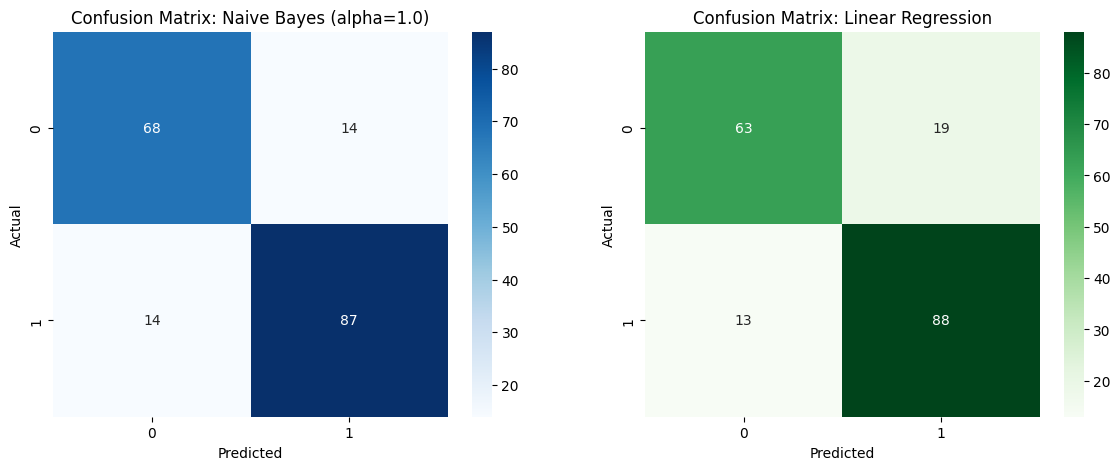

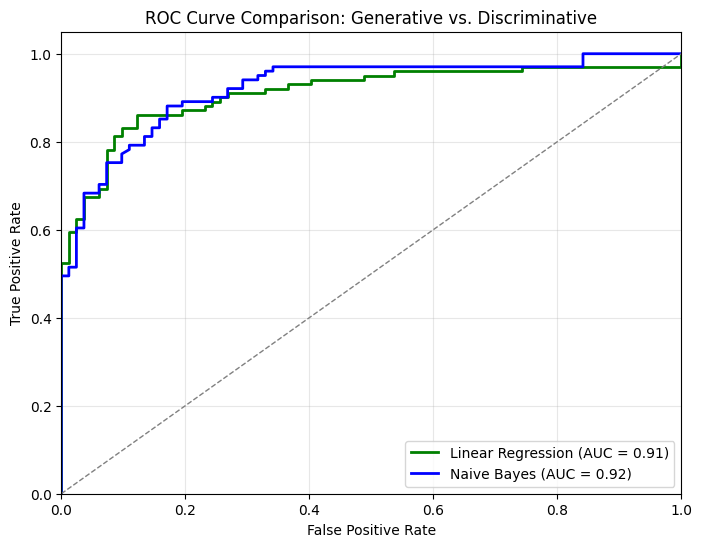

Naive Bayes -> AUC: 0.922
Linear Regression -> AUC: 0.911


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix: Naive Bayes
sns.heatmap(confusion_matrix(y_test, y_pred_nb1), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Naive Bayes (alpha=1.0)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Compute Precision, Recall, F1 for NB
precision_nb = precision_score(y_test, y_pred_nb1)
recall_nb = recall_score(y_test, y_pred_nb1)
f1_nb = f1_score(y_test, y_pred_nb1)
print(f"Naive Bayes (alpha=1.0) -> Precision: {precision_nb:.3f}, Recall: {recall_nb:.3f}, F1-score: {f1_nb:.3f}")

# Confusion Matrix: Linear Regression
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix: Linear Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Compute Precision, Recall, F1 for LR
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print(f"Linear Regression -> Precision: {precision_lr:.3f}, Recall: {recall_lr:.3f}, F1-score: {f1_lr:.3f}")

plt.show()
plt.figure(figsize=(8, 6))

# ROC Curve for Linear Regression
y_scores_lr = lr.predict(X_test_processed) # Continuous output serves as scores
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_scores_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'Linear Regression (AUC = {roc_auc_lr:.2f})')

# # ROC Curve for Naive Bayes ROC
y_probs_nb = nb_1.predict_proba(X_test_processed)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_probs_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, color='blue', lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')

# Plotting formatting
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--') # Luck line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Generative vs. Discriminative')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Print metrics for your report
print(f"Naive Bayes -> AUC: {roc_auc_nb:.3f}")
print(f"Linear Regression -> AUC: {roc_auc_lr:.3f}")